In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
main_df = pd.read_csv(
    '/kaggle/input/datasets/cm037divya/pcos-dataset/PCOS_extended_dataset.csv'
)
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3    Age (yrs)              2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   

In [2]:
main_df.isna().sum()
main_df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


In [3]:
class DataPreprocessor:
    """
    Advanced data preprocessing pipeline for clinical PCOS data
    """
    def __init__(self):
        self.label_encoders = {}
        self.scalers = {}
        self.imputers = {}
        self.feature_names = None
        
    def clean_main_dataset(self, df):
        """Clean and preprocess the main PCOS dataset"""
        df_clean = df.copy()

        # -------------------------------
        # 1. Clean column names
        # -------------------------------
        df_clean.columns = df_clean.columns.str.strip()

        # -------------------------------
        # 2. Rename columns
        # -------------------------------
        column_mapping = {
            'PCOS (Y/N)': 'PCOS_Diagnosis',
            'Age (yrs)': 'Age',
            'Weight (Kg)': 'Weight_Kg',
            'Height(Cm)': 'Height_Cm',
            'BMI': 'BMI',
            'Blood Group': 'Blood_Group',
            'Pulse rate(bpm)': 'Pulse_Rate',
            'RR (breaths/min)': 'Respiratory_Rate',
            'Hb(g/dl)': 'Hemoglobin',
            'Cycle(R/I)': 'Cycle_Regularity',
            'Cycle length(days)': 'Cycle_Length_Days',
            'Marraige Status (Yrs)': 'Marriage_Duration_Yrs',
            'Pregnant(Y/N)': 'Pregnant',
            'No. of aborptions': 'Abortions',
            'I beta-HCG(mIU/mL)': 'Beta_HCG_I',
            'II beta-HCG(mIU/mL)': 'Beta_HCG_II',
            'AMH(ng/mL)': 'AMH',
            'Vit D3 (ng/mL)': 'Vit_D3',
            'PRG(ng/mL)': 'Progesterone',
            'RBS(mg/dl)': 'Random_Blood_Sugar',
            'Weight gain(Y/N)': 'Weight_Gain',
            'hair growth(Y/N)': 'Hair_Growth',
            'Skin darkening (Y/N)': 'Skin_Darkening',
            'Hair loss(Y/N)': 'Hair_Loss',
            'Pimples(Y/N)': 'Pimples',
            'Fast food (Y/N)': 'Fast_Food',
            'Reg.Exercise(Y/N)': 'Regular_Exercise',
            'BP _Systolic (mmHg)': 'BP_Systolic',
            'BP _Diastolic (mmHg)': 'BP_Diastolic',
            'Follicle No. (L)': 'Follicle_No_Left',
            'Follicle No. (R)': 'Follicle_No_Right',
            'Avg. F size (L) (mm)': 'Avg_Follicle_Size_Left',
            'Avg. F size (R) (mm)': 'Avg_Follicle_Size_Right',
            'Endometrium (mm)': 'Endometrium',
            'Waist:Hip Ratio': 'Waist_Hip_Ratio',
            'TSH (mIU/L)': 'TSH',
            'FSH(mIU/mL)': 'FSH',
            'LH(mIU/mL)': 'LH',
            'FSH/LH': 'FSH_LH_Ratio',
            'Hip(inch)': 'Hip_Inch',
            'Waist(inch)': 'Waist_Inch'
        }

        df_clean.rename(columns=column_mapping, inplace=True)

        # -------------------------------
        # 3. Clean string values
        # -------------------------------
        for col in df_clean.select_dtypes(include='object').columns:
            df_clean[col] = df_clean[col].astype(str).str.strip()

        # -------------------------------
        # 4. Convert binary columns (Y/N → 1/0)
        # -------------------------------
        binary_map = {'Y': 1, 'N': 0, 'Yes': 1, 'No': 0}

        for col in df_clean.columns:
            if df_clean[col].dtype == 'object':
                test_series = df_clean[col].astype(str).str.strip()
                if test_series.isin(['Y', 'N', 'Yes', 'No']).any():
                    df_clean[col] = test_series.map(binary_map)

        # -------------------------------
        # 5. Fix mixed-type columns
        # -------------------------------
        for col in df_clean.columns:
            if col != 'PCOS_Diagnosis': # Skip target variable if it's already structured
                # Check if it should be numeric (ignoring known non-numeric columns like Blood_Group)
                if col not in ['Blood_Group']: 
                    # errors='coerce' flushes out hidden text/spaces into standard NaNs
                    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

        # -------------------------------
        # 6. Separate columns
        # -------------------------------
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        categorical_cols = df_clean.select_dtypes(include=['object']).columns

        # -------------------------------
        # 7. Imputation
        # -------------------------------
        if len(numeric_cols) > 0:
            self.imputers['numeric'] = SimpleImputer(strategy='median')
            df_clean[numeric_cols] = self.imputers['numeric'].fit_transform(df_clean[numeric_cols])

        if len(categorical_cols) > 0:
            # Convert all categorical strictly to string
            df_clean[categorical_cols] = df_clean[categorical_cols].astype(str)

            self.imputers['categorical'] = SimpleImputer(strategy='most_frequent')
            df_clean[categorical_cols] = self.imputers['categorical'].fit_transform(df_clean[categorical_cols])

        return df_clean

    def create_advanced_features(self, df):
        """Feature engineering"""
        df = df.copy()

        if all(col in df.columns for col in ['BMI', 'Age']):
            df['BMI_Age_Ratio'] = df['BMI'] / df['Age'].clip(lower=18)
            df['Obesity_Risk'] = (df['BMI'] > 30).astype(int)

        if all(col in df.columns for col in ['LH', 'FSH']):
            df['LH_FSH_Ratio'] = df['LH'] / df['FSH'].clip(lower=0.1)
            df['Elevated_LH_FSH'] = (df['LH_FSH_Ratio'] > 2).astype(int)

        if 'Waist_Hip_Ratio' in df.columns:
            df['WHR_Elevated'] = (df['Waist_Hip_Ratio'] > 0.85).astype(int)

        symptom_cols = [
            'Weight_Gain', 'Hair_Growth', 'Skin_Darkening',
            'Hair_Loss', 'Pimples', 'Cycle_Regularity'
        ]

        available = [col for col in symptom_cols if col in df.columns]

        if available:
            df['Symptom_Severity_Score'] = df[available].sum(axis=1)

        return df


preprocessor = DataPreprocessor()
main_df_clean = preprocessor.clean_main_dataset(main_df)

main_df_features_after_feature_eng = preprocessor.create_advanced_features(main_df_clean)

print("✅ Main dataset:", main_df_clean.shape)
main_df_clean.head()
print(main_df_clean['PCOS_Diagnosis'].sum())

✅ Main dataset: (2000, 44)
608.0


In [4]:
# Dataset cleaning by dropping the serial No. and Patient File No. columns 
# main_df_clean.drop(columns = ['Sl. No','Patient File No.'],inplace = True)
y = main_df_clean['PCOS_Diagnosis']
X = main_df_clean.drop(columns='PCOS_Diagnosis')
X['II    beta-HCG(mIU/mL)'] = pd.to_numeric(X['II    beta-HCG(mIU/mL)'], errors='coerce')
X['AMH'] = pd.to_numeric(X['AMH'],errors = 'coerce')
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sl. No                   2000 non-null   float64
 1   Patient File No.         2000 non-null   float64
 2   Age                      2000 non-null   float64
 3   Weight_Kg                2000 non-null   float64
 4   Height_Cm                2000 non-null   float64
 5   BMI                      2000 non-null   float64
 6   Blood_Group              2000 non-null   float64
 7   Pulse_Rate               2000 non-null   float64
 8   Respiratory_Rate         2000 non-null   float64
 9   Hemoglobin               2000 non-null   float64
 10  Cycle_Regularity         2000 non-null   float64
 11  Cycle_Length_Days        2000 non-null   float64
 12  Marriage_Duration_Yrs    2000 non-null   float64
 13  Pregnant                 2000 non-null   float64
 14  No. of abortions        

# Random Forest

In [5]:
# Random Forest implementation
from sklearn.model_selection import train_test_split

train_size = len(X) *0.7
test_size = len(X) * 0.3

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=0
)

RF.fit(X_train,y_train)
accuracy = RF.score(X_train,y_train)
val_accuracy = RF.score(X_test,y_test)

print('Train Accuracy',accuracy)

Train Accuracy 0.9978571428571429


In [6]:
predictions = RF.predict(X_test)
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       399
         1.0       1.00      0.94      0.97       201

    accuracy                           0.98       600
   macro avg       0.98      0.97      0.98       600
weighted avg       0.98      0.98      0.98       600



# **A Custom Stacked Ensemble built using Base estimator(RF,XGBoost,SVM) and Meta Classifiers(Logistic Regression)**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Spliting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Defining Base Estimators
base_estimators = [
    ('rf', RandomForestClassifier(n_estimators=150, max_depth=7, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, eval_metric='logloss', random_state=42)),
    ('svm', Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', probability=True, C=1.0, random_state=42))
    ]))
]
# Defining Our Meta Estimator
meta_estimator = LogisticRegression(max_iter=1000, random_state=42)
# Our Stacked model
stacked_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=5,
    n_jobs=-1,
    passthrough=False 
)

print('Training Custom Ensembled Model')
stacked_model.fit(X_train,y_train)
y_pred = stacked_model.predict(X_test)

central_accuracy = accuracy_score(y_test, y_pred)
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Custom Ensembled Model

Model Performance Metrics:
Accuracy: 0.9950

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       263
         1.0       0.99      0.99      0.99       137

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



# **Smotnec Class balancing** 
Smotnec is applied to test the results on the balanced classes to measure performance difference of the models

In [8]:
from imblearn.over_sampling import SMOTENC

categorical_features_indices = []
for index, col in enumerate(X.columns):
    # If the column has only 2 unique values, it's a binary categorical feature
    if X[col].nunique() <= 2:
        categorical_features_indices.append(index)
# Smotnec initialization
smote_nc = SMOTENC(categorical_features=categorical_features_indices, random_state=42, k_neighbors=5)

X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

print(f"After SMOTE - Class Distribution: {dict(pd.Series(y_train_resampled).value_counts())}")

After SMOTE - Class Distribution: {1.0: np.int64(1129), 0.0: np.int64(1129)}


# After Applying on the Data

In [9]:
print('Training Custom Ensembled Model')
stacked_model.fit(X_train_resampled,y_train_resampled)
y_pred = stacked_model.predict(X_test)

print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Custom Ensembled Model

Model Performance Metrics:
Accuracy: 0.9950

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       263
         1.0       0.99      0.99      0.99       137

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



In [10]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# JavaScript visualization is initialized for the notebook
shap.initjs()

# This guarantees that the column names are preserved during SHAPs process
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)
y_train_resampled_series = pd.Series(y_train_resampled)

# 2. Re-verify that the Stacking Classifier is fitted on the resampled data
print("Ensuring Stacking Classifier is fitted...")
stacked_model.fit(X_train_resampled_df, y_train_resampled_series)

# 3. Create a background summary coreset using K-means clustering
# Rather than using all resampled samples, we extract 50 representative centroids
print("Summarizing background dataset via K-means (balancing speed and fidelity)...")
background_coreset = shap.kmeans(X_train_resampled_df, 50)

# 4. Define a clean 1D prediction wrapper for the binary target variable
def predict_pcos_probability(data_matrix):
    """
    Takes an input matrix (numpy array or dataframe) and returns a 1D array 
    representing the probability of a positive PCOS diagnosis (Class 1).
    """
    # If SHAP passes a numpy array, convert it to a DataFrame with original features to prevent errors
    if isinstance(data_matrix, np.ndarray):
        data_matrix = pd.DataFrame(data_matrix, columns=X_train_resampled_df.columns)
    
    # Getting 2D probabilities: [P(class_0), P(class_1)]
    probs = stacked_model.predict_proba(data_matrix)
    
    # Return P(PCOS Positive)
    return probs[:, 1]

# 5. Initialize the Kernel SHAP Explainer
print("Initializing model-agnostic Kernel SHAP Explainer...")
centralized_explainer = shap.KernelExplainer(predict_pcos_probability, background_coreset)

Ensuring Stacking Classifier is fitted...
Summarizing background dataset via K-means (balancing speed and fidelity)...
Initializing model-agnostic Kernel SHAP Explainer...


In [11]:
# Converting test set to a clean DataFrame to preserve feature headers
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)

# Select an evaluation cohort (e.g., the first 30 patients from the test set)
# These represent the patient profiles we will explain in detail
evaluation_cohort = X_test_df.iloc[:30]

print(f"Calculating Shapley attributions for {len(evaluation_cohort)} test profiles...")
# nsamples="auto" dynamically balances speed and estimation accuracy
shap_values_centralized = centralized_explainer.shap_values(evaluation_cohort, nsamples="auto")

print("✅ SHAP values successfully calculated!")
print(f"SHAP matrix dimensions: {shap_values_centralized.shape}")

Calculating Shapley attributions for 30 test profiles...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ SHAP values successfully calculated!
SHAP matrix dimensions: (30, 43)


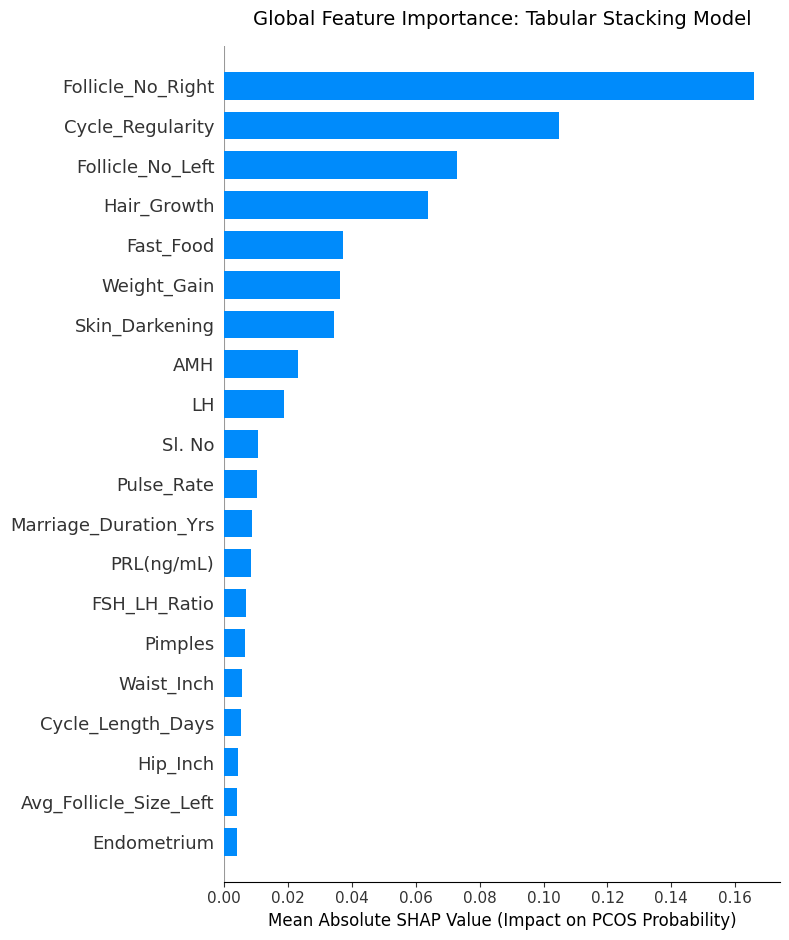

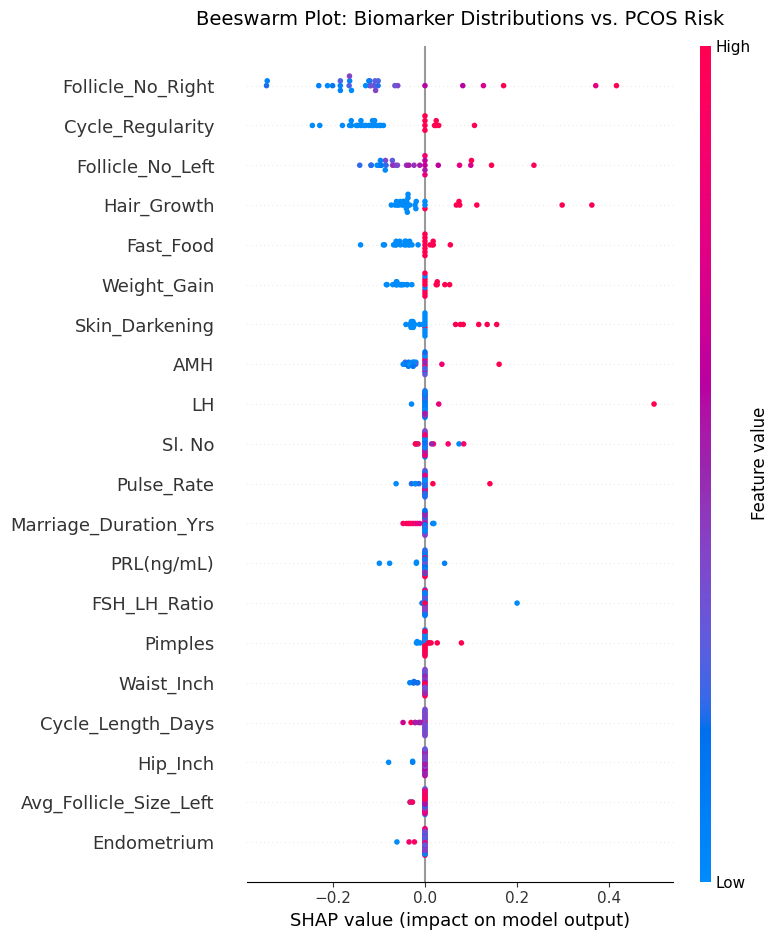

In [12]:
# 1. Global Feature Importance Bar Plot
# This displays the mean absolute SHAP value for each feature
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance: Tabular Stacking Model", fontsize=14, pad=15)
shap.summary_plot(
    shap_values_centralized, 
    evaluation_cohort, 
    plot_type="bar", 
    feature_names=X_test_df.columns, 
    show=False
)
plt.xlabel("Mean Absolute SHAP Value (Impact on PCOS Probability)", fontsize=12)
plt.tight_layout()
plt.show()

# 2. Beeswarm Summary Plot
# This maps feature values (high/low in red/blue) against their positive/negative impact
plt.figure(figsize=(12, 7))
plt.title("Beeswarm Plot: Biomarker Distributions vs. PCOS Risk", fontsize=14, pad=15)
shap.summary_plot(
    shap_values_centralized, 
    evaluation_cohort, 
    feature_names=X_test_df.columns, 
    show=False
)
# Note: Features like AMH, LH_FSH_Ratio, and DHEAS will typically cluster at the top [2]
plt.tight_layout()
plt.show()

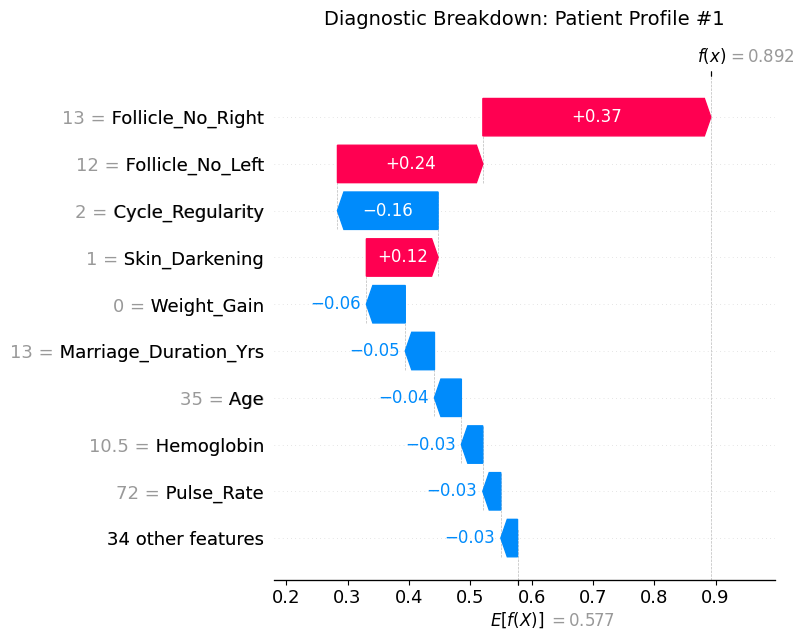

In [13]:
# Select a specific patient index to explain (e.g., patient #0)
patient_index = 1
single_patient_profile = evaluation_cohort.iloc[patient_index]
single_patient_shap = shap_values_centralized[patient_index]

# Create an Explanation object required for SHAP's local plotting modules
patient_explanation = shap.Explanation(
    values=single_patient_shap,
    base_values=centralized_explainer.expected_value, # The baseline/mean probability of the cohort
    data=single_patient_profile.values,
    feature_names=X_test_df.columns
)

# Plot a Waterfall diagram for this specific patient
plt.figure(figsize=(10, 5))
plt.title(f"Diagnostic Breakdown: Patient Profile #{patient_index}", fontsize=14, pad=15)
shap.plots.waterfall(patient_explanation, max_display=10, show=False)
plt.tight_layout()
plt.show()

# Horizontal FL and the Stacking Aggregation Challenge
The FedAvg is highly compatible for the Neural Networks but it is mathematically impossible for the stack(My ensemble stack of XGBoost,RF and SVM trained on the data).

The Proposed Solution Workflow is:

We split our SMOTE-NC balanced training set into $K=5$ independent shards representing private clinic databases . We use a Dirichlet distribution with concentration parameter `$\alpha = 1.0$` to simulate realistic, non-IID (statistically heterogeneous) label skew across clinics .

Each clinic trains its own local copy of your StackingClassifier on its private, locally balanced data shard ``.

During testing/inference, rather than sharing raw weights, the global federated system queries the local classifiers and aggregates their predictions by computing the average of their predicted class probability vectors ``.

In [14]:
import numpy as np
import pandas as pd
from sklearn.base import clone

np.random.seed(42)


if isinstance(X_train, pd.DataFrame):
    X_train_resampled_df = pd.DataFrame(
        X_train_resampled,
        columns=X_train.columns
    )
else:
    X_train_resampled_df = pd.DataFrame(X_train_resampled)

y_train_resampled_series = pd.Series(y_train_resampled)

# Federated Learning Configuration

num_clients = 5
alpha_dirichlet = 1.0

print(
    f"Partitioning training data into {num_clients} clinics "
    f"using Dirichlet distribution (alpha={alpha_dirichlet})...\n"
)

# Non-IID Dirichlet Partitioning

classes = np.unique(y_train_resampled_series)

# Dictionary storing sample indices for each client
client_indices = {i: [] for i in range(num_clients)}

for c in classes:

    # Get indices belonging to class c
    idx_c = y_train_resampled_series[
        y_train_resampled_series == c
    ].index.values

    # Shuffling indices
    np.random.shuffle(idx_c)

    # Sample Dirichlet proportions
    proportions = np.random.dirichlet(
        [alpha_dirichlet] * num_clients
    )

    # Convert proportions to integer counts
    proportions = (proportions * len(idx_c)).astype(int)

    start = 0

    for client_id in range(num_clients):

        if client_id == num_clients - 1:
            # Last client gets all remaining samples
            client_indices[client_id].extend(idx_c[start:])
        else:
            end = start + proportions[client_id]
            client_indices[client_id].extend(idx_c[start:end])
            start = end

# Create Local Client Datasets

client_data = []

print("Client Data Statistics:\n")

for client_id in range(num_clients):

    idxs = client_indices[client_id]

    X_local = (
        X_train_resampled_df
        .iloc[idxs]
        .reset_index(drop=True)
    )

    y_local = (
        y_train_resampled_series
        .iloc[idxs]
        .reset_index(drop=True)
    )

    client_data.append((X_local, y_local))

    pos_count = (y_local == 1).sum()
    neg_count = (y_local == 0).sum()

    print(
        f"Clinic #{client_id + 1}: "
        f"{len(X_local)} patients | "
        f"Positives: {pos_count}, "
        f"Negatives: {neg_count}"
    )

    if len(X_local) == 0:
        print(f" Clinic #{client_id + 1} has no samples!")

print("\nData partitioning completed successfully.")

Partitioning training data into 5 clinics using Dirichlet distribution (alpha=1.0)...

Client Data Statistics:

Clinic #1: 460 patients | Positives: 437, Negatives: 23
Clinic #2: 813 patients | Positives: 274, Negatives: 539
Clinic #3: 392 patients | Positives: 57, Negatives: 335
Clinic #4: 197 patients | Positives: 192, Negatives: 5
Clinic #5: 396 patients | Positives: 169, Negatives: 227

Data partitioning completed successfully.


In [15]:
from sklearn.metrics import accuracy_score

# Store all locally trained models
federated_local_models = []

print("Initiating Decentralized Client Training on Local EHR Shards...")

for client_id in range(num_clients):

    print(f"\n[Clinic {client_id + 1}] Training Local Stacking Ensemble...")

    X_local, y_local = client_data[client_id]

    if len(X_local) == 0:
        print("No samples available. Skipping...")
        continue

    # Clone the global architecture
    local_stacked_model = clone(stacked_model)

    # Train locally
    local_stacked_model.fit(X_local, y_local)

    # Save local model
    federated_local_models.append(local_stacked_model)

    # Evaluate on local training data
    local_preds = local_stacked_model.predict(X_local)
    local_acc = accuracy_score(y_local, local_preds)

    print(f"Clinic {client_id + 1} Local Train Accuracy: {local_acc:.4f}")

print("\nAll decentralized client models trained successfully.")

Initiating Decentralized Client Training on Local EHR Shards...

[Clinic 1] Training Local Stacking Ensemble...
Clinic 1 Local Train Accuracy: 1.0000

[Clinic 2] Training Local Stacking Ensemble...
Clinic 2 Local Train Accuracy: 0.9988

[Clinic 3] Training Local Stacking Ensemble...
Clinic 3 Local Train Accuracy: 0.9974

[Clinic 4] Training Local Stacking Ensemble...
Clinic 4 Local Train Accuracy: 0.9746

[Clinic 5] Training Local Stacking Ensemble...
Clinic 5 Local Train Accuracy: 0.9975

All decentralized client models trained successfully.


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

# Reconstructing unseen test set
X_test_df = pd.DataFrame(X_test, columns=X_train.columns)
y_test_series = pd.Series(y_test)

# 1. Define Global Prediction Aggregator (Weighted Probability Voting)
def federated_predict_probabilities(X_input):

    client_probabilities = []

    for model in federated_local_models:
        probs = model.predict_proba(X_input)
        client_probabilities.append(probs)

    mean_probabilities = np.mean(client_probabilities, axis=0)

    return mean_probabilities

# 2. Generate Predictions
fed_test_probabilities = federated_predict_probabilities(X_test_df)
fed_test_predictions = np.argmax(fed_test_probabilities, axis=1)

fed_accuracy = accuracy_score(
    y_test_series,
    fed_test_predictions
)

print("\n" + "="*50)
print("     FEDERATED VS. CENTRALIZED PERFORMANCE")
print("="*50)
print(f"Centralized Model Test Accuracy : {central_accuracy:.4f}")
print(f"Federated Model Test Accuracy :     {fed_accuracy:.4f}")
print(f"Absolute Performance Trade-Off:            {central_accuracy - fed_accuracy:.4f}")
print("="*72)

# Print detailed Classification Report for the Federated model
print("\nFederated Model Classification Report:")
print(classification_report(y_test_series, fed_test_predictions))


     FEDERATED VS. CENTRALIZED PERFORMANCE
Centralized Model Test Accuracy : 0.9950
Federated Model Test Accuracy :     0.9600
Absolute Performance Trade-Off:            0.0350

Federated Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.96      0.97       263
         1.0       0.92      0.96      0.94       137

    accuracy                           0.96       400
   macro avg       0.95      0.96      0.96       400
weighted avg       0.96      0.96      0.96       400

